In [1]:
!pip install langgraph langsmith langchain langchain_groq langchain_community

In [2]:
from typing import Annotated
from typing_extensions import TypedDict

In [3]:
!pip install arxiv wikipedia

In [4]:
## Working With Tools

from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun

## Arxiv And Wikipedia tools
arxiv_wrapper=ArxivAPIWrapper(top_k_results=1,doc_content_chars_max=300)
arxiv_tool=ArxivQueryRun(api_wrapper=arxiv_wrapper)

api_wrapper=WikipediaAPIWrapper(top_k_results=1,doc_content_chars_max=300)
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [5]:
wiki_tool.invoke("who is Christopher Nolan?")

'Page: Christopher Nolan filmography\nSummary: Sir Christopher Nolan is a British-American film director, screenwriter, and film producer. His feature directorial debut was the neo-noir crime thriller  Following (1998) which was made on a budget of $6,000. Two years later, he directed the psychologica'

In [6]:
arxiv_tool.invoke("Attention is all you need")

'Published: 2021-05-06\nTitle: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet\nAuthors: Luke Melas-Kyriazi\nSummary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their mult'

In [7]:
tools=[wiki_tool]

In [8]:
## Langgraph Application
from langgraph.graph.message import add_messages
class State(TypedDict):
  messages:Annotated[list,add_messages]

In [9]:
from langgraph.graph import StateGraph,START,END

In [44]:
graph_builder= StateGraph(State)


In [45]:
from langchain_groq import ChatGroq

In [49]:
import os
from dotenv import load_dotenv

load_dotenv()
groq_api_key = os.getenv("GROQ_API_KEY")

In [48]:
key = os.getenv("GROQ_API_KEY")

In [50]:
llm = ChatGroq(groq_api_key=groq_api_key, model_name="llama-3.3-70b-versatile")
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 32768, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x0000027D16104050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x0000027D15904D10>, model_name='llama-3.3-70b-versatile', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [51]:
llm_with_tools=llm.bind_tools(tools=tools)

In [52]:
def chatbot(state:State):
  return {"messages":[llm_with_tools.invoke(state["messages"])]}

In [53]:
from langgraph.prebuilt import ToolNode,tools_condition

In [54]:
graph_builder.add_node("chatbot",chatbot)
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START,"chatbot")


In [55]:
graph=graph_builder.compile()

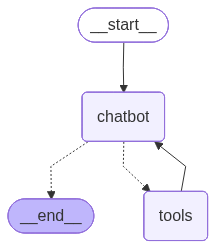

In [56]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    # This requires some extra dependencies and is optional
    pass

In [59]:
user_input="ronaldo's age?"

events=graph.stream(
     {"messages": [("user", user_input)]},stream_mode="values"
)

for event in events:
  event["messages"][-1].pretty_print()

================================ Human Message =================================

ronaldo's age?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (2a10rhvpd)
 Call ID: 2a10rhvpd
  Args:
    query: Cristiano Ronaldo age
================================= Tool Message =================================
Name: wikipedia

Page: Cristiano Ronaldo
Summary: Cristiano Ronaldo dos Santos Aveiro (born 5 February 1985), nicknamed CR7, is a Portuguese professional footballer who plays as a forward for and captains both Saudi Pro League club Al-Nassr and the Portugal national team. Widely regarded as one of the greatest playe
================================== Ai Message ==================================



Cristiano Ronaldo is 38 years old.


In [61]:
user_input = "where is india?"

# The config is the **second positional argument** to stream() or invoke()!
events = graph.stream(
    {"messages": [("user", user_input)]},stream_mode="values"
)
for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

where is india?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (0850hem5e)
 Call ID: 0850hem5e
  Args:
    query: India location
================================= Tool Message =================================
Name: wikipedia

Page: India
Summary: India, officially the Republic of India, is a country in South Asia.  It is the seventh-largest country by area; the most populous country since 2023; and, since its independence in 1947, the world's most populous democracy. Bounded by the Indian Ocean on the south, the Arabian 
================================== Ai Message ==================================

India is located in South Asia, bounded by the Indian Ocean on the south, the Arabian Sea on the southwest, and the Bay of Bengal on the southeast. It shares borders with several countries, including Pakistan to the west, China and Nepal to the north